<a href="https://colab.research.google.com/github/felipekenjidev/performance-estudantes/blob/main/miniprojetods_performance_estudantes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Mini Projeto 2026 - Performance dos Estudantes**
O **Mini Projeto Performance dos Estudantes** é um projeto desenvolvido em Python com apoio da **Liga de Data Science da Unicamp**.

O objetivo do trabalho é analisar um dataset sobre as características dos estudantes, e gerar insights e correlações sobre as variáveis que mais impactam na performance escolar/universitária de um aluno.

**Integrantes:**
- Felipe Kenji Ouba Fukuzono
- Thiago Henrique da Silva dos Santos
- Giovanna Mota Freire
- Julia Duarte Mira Marques

## **Etapa 1 - Tratamento de Dados**
Carregar e limpar o dataset inicial, tratando possíveis valores vazios, duplicados ou discrepantes que podem atrapalhar a análise.

### **Etapa 1.1 - Download do Dataset**
Fazer o download do dataset diretamente pelo Kagglehub, com objetivo de facilitar e agilizar o projeto.


In [11]:
# Importar Bibliotecas do Python
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Baixar o Arquivo Dataset direto do Kaggle
print('--- OBTER O ARQUIVO DATASET ---')
path = kagglehub.dataset_download('devansodariya/student-performance-data')

--- OBTER O ARQUIVO DATASET ---
Using Colab cache for faster access to the 'student-performance-data' dataset.


### **Etapa 1.2 - Carregamento do Dataset**
Carregar o dataset para dentro de um dataframe, com objetivo de obter uma melhor visualização e poder manipular suas informações.

In [12]:
# Importar Bibliotecas do Python
import pandas as pd
import os

# Encontrar o Arquivo CSV
arquivo_csv = os.path.join(path, 'student_data.csv')

# Abrir o Arquivo Dataset
df = pd.read_csv(arquivo_csv)

# Exibir o DataFrame
print('--- EXIBIÇÃO DO DATASET EM FORMATO DE TABELA ---')
display(df.head())

--- EXIBIÇÃO DO DATASET EM FORMATO DE TABELA ---


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


### **Etapa 1.3 - Visualização de Valores Nulos**
Visualizar as informações do dataframe, verificando a quantidade de linhas e colunas, e verificando se há algum valor nulo.

*Ps: Como foi verificado que não há nenhum valor nulo, não houve necessidade de tratamento de valores nulos.*

In [13]:
# Verificar a Quantidade de Linhas por Colunas
print('--- QUANTIDADE DE LINHAS/COLUNAS ---')
print(df.shape)

# Exibir Nome de Todas as Colunas Presentes
print('\n--- NOME DAS COLUNAS ---')
print(df.columns)

# Exibir as Colunas e a Quantidade de Valores Presentes
print('\n--- COLUNAS E SEUS VALORES ---')
print(df.info())

# Contar o Número de Linhas com Valores Ausentes
print('\n--- DADOS DAS LINHAS ---')
print(f'Número de linhas do dataset: {len(df)}')
print(f'Número de linhas com pelo menos um valor ausente: {df.isna().sum().sum()}')

--- QUANTIDADE DE LINHAS/COLUNAS ---
(395, 33)

--- NOME DAS COLUNAS ---
Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')

--- COLUNAS E SEUS VALORES ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   

### **Etapa 1.4 - Visualização de Valores Duplicados**
Verificar as informações do dataframe, observando se há algum valor duplicado discrepante, que pode atrapalhar as análises, no dataframe.

*Ps: Como foi verificado que não há nenhum valor repetido, não houve necessidade de tratamento.*

In [14]:
# Identificar Linhas Duplicadas no Dataframe
num_duplicadas = df.duplicated().sum()

# Exibir o Número de Linhas Duplicadas
print('--- EXIBIÇÃO DE LINHAS DUPLICADAS ---')
if num_duplicadas > 0:
    print('Primeiras 5 linhas duplicadas (mantendo a primeira ocorrência):')
    display(df[df.duplicated()].head())
else:
    print('Não há linhas duplicadas para exibir.')

--- EXIBIÇÃO DE LINHAS DUPLICADAS ---
Não há linhas duplicadas para exibir.


### **Etapa 1.5 - Verificação de Frequência de Categorias**
Verificar a frequência de cada categoria do dataframe, com objetivo de encontrar possíveis valores, com frequências extremamente baixas, que poluem o dataset.

*Ps: Utilizando como referência um α = 5%, existe somente uma categoria que está abaixo do limite proposto, a Fjob_health. Como não existe mais nenhuma categoria abaixo do limite, que poluem o dataset, não há motivos para tratá-los.*

In [15]:
# Declarar Variável das Colunas Categóricas
colunas_alvo = ['Mjob', 'Fjob', 'reason', 'guardian']

# Exibir a Frequência de Cada Categoria das Colunas Categóricas
print('--- EXIBIÇÃO DE FREQUÊNCIA DE CATEGORIAS ---')
for coluna in colunas_alvo:
  print(f'{df[coluna].value_counts(normalize=True)}\n')

--- EXIBIÇÃO DE FREQUÊNCIA DE CATEGORIAS ---
Mjob
other       0.356962
services    0.260759
at_home     0.149367
teacher     0.146835
health      0.086076
Name: proportion, dtype: float64

Fjob
other       0.549367
services    0.281013
teacher     0.073418
at_home     0.050633
health      0.045570
Name: proportion, dtype: float64

reason
course        0.367089
home          0.275949
reputation    0.265823
other         0.091139
Name: proportion, dtype: float64

guardian
mother    0.691139
father    0.227848
other     0.081013
Name: proportion, dtype: float64



### **Etapa 1.6 - Identificação de Colunas com Variância Quase Zero**
Fazer código para analisar variância de todas as coluna (ou fazer value_count). Se alguma coluna tiver mais de 95% das respostas concentradas numa única opção (ex: 96% dos alunos pertencem à mesma escola), essa coluna não tem poder de diferenciação



Foi avaliado que as colunas **higher**, **Pstatus** e **school** serão **excluídas** tanto da modelagem preditiva (Machine Learning) quanto das análises visuais e geração de gráficos.

A decisão de descartar completamente estas variáveis baseia-se no critério estatístico de Variância Quase Zero. Dados excessivamente concentrados em uma única resposta perdem o poder de diferenciação, o que significa que:

- Para os modelos de ML: Elas não acrescentam valor para que o algoritmo aprenda os padrões de comportamento dos estudantes.

- Para os gráficos: Qualquer cruzamento visual gerará plots severamente desproporcionais e distorcidos, impossibilitando comparações justas ou a extração de insights que sejam estatisticamente confiáveis devido à falta de dados no grupo minoritário.

Abaixo detalha-se a justificativa técnica para a exclusão total de cada uma delas:

-  **higher** (Ambição de frequentar o Ensino Superior): 94,94% dos alunos responderam "SIM" (375 estudantes contra apenas 20 que responderam "não"). Como a esmagadora maioria tem o mesmo objetivo, esta variável comporta-se praticamente como uma constante no dataset. Nos gráficos, a sub-representação extrema (apenas 20 pessoas) tornaria qualquer comparação de notas visualmente desequilibrada e sem relevância científica.

- **Pstatus** (Status de união dos pais): 89,62% dos pais dos alunos vivem juntos (354 casos). Com apenas 10,38% (41 alunos) de pais separados, a amostra é muito pequena. Tentar cruzar essa variável graficamente com a qualidade da relação familiar ou com as notas geraria gráficos enganosos, pois não há dados volumosos o suficiente do grupo de pais separados para confrontar com o grupo majoritário.

- **school** (Escola de origem do estudante): Esta coluna apresenta 88,35% dos dados concentrados na escola GP (349 alunos contra apenas 46 da escola MS). Devido a esse forte desbalanceamento populacional, manter a variável na análise induziria a gerar gráficos que refletem quase exclusivamente o padrão de uma das instituições. Como a escola MS está severamente sub-representada, o parâmetro escolar torna-se irrelevante para traçar paralelos visuais ou preditivos gerais.

In [17]:
print('--- ANÁLISE DE TENDÊNCIAS E PROPORÇÃO DE RESPOSTAS (TODAS AS COLUNAS) ---\n')

# Vamos percorrer todas as colunas do dataset automaticamente
for coluna in df.columns:
    print(f"==================================================")
    print(f"COLUNA: {coluna.upper()}")
    print(f"==================================================")

    # 1. Conta a quantidade absoluta de cada resposta
    contagem = df[coluna].value_counts()

    # 2. Calcula a porcentagem de cada resposta (multiplicamos por 100 e arredondamos)
    porcentagem = df[coluna].value_counts(normalize=True) * 100

    # 3. Junta as duas informações em um novo DataFrame para exibir bonitinho lado a lado
    analise_coluna = pd.DataFrame({
        'Quantidade': contagem,
        'Porcentagem (%)': porcentagem.round(2)
    })

    display(analise_coluna)
    print("\n") # Dá um espaço entre as colunas para não virar bagunça

--- ANÁLISE DE TENDÊNCIAS E PROPORÇÃO DE RESPOSTAS (TODAS AS COLUNAS) ---

COLUNA: SCHOOL


,Quantidade,Porcentagem (%)
school,,
GP,349,88.35
MS,46,11.65




COLUNA: SEX


,Quantidade,Porcentagem (%)
sex,,
F,208,52.66
M,187,47.34




COLUNA: AGE


...

,Quantidade,Porcentagem (%)
G1,,
10,51,12.91
8,41,10.38
11,39,9.87
7,37,9.37
12,35,8.86
13,33,8.35
9,31,7.85
14,30,7.59
15,24,6.08




COLUNA: G2


,Quantidade,Porcentagem (%)
G2,,
9,50,12.66
10,46,11.65
12,41,10.38
13,37,9.37
11,35,8.86
15,34,8.61
8,32,8.10
14,23,5.82
7,21,5.32




COLUNA: G3


,Quantidade,Porcentagem (%)
G3,,
10,56,14.18
11,47,11.90
0,38,9.62
15,33,8.35
8,32,8.10
12,31,7.85
13,31,7.85
9,28,7.09
14,27,6.84


### **Etapa 1.7 - Verificação de Hipóteses Nulas**
Verificar se os dados que estão sendo estudados, possuem efetivamente uma relação ou algum tipo de tendência. Isso é feito testando as hipóteses nulas, ou seja, testando se os valores são apenas fruto do acaso, com o p-value.

*Ps: Utilizando como referência uma margem de aceitação de 5%, descobrimos que o p-value é muito menor que isso, então nos afirmando que as notas não são puramente aleatórias e são afetadas por outros fatores que devemos estudar.*

In [49]:
# Importar Bibliotecas do Python
import numpy as np
from scipy import stats

# Criar Nova Coluna de Média de Notas
df['média'] = df[['G1', 'G2', 'G3']].mean(axis=1)

# Normalização dos Dados para Uma Escala Normal (0 a 1)
dados_normalizados = (df['média'] - df['média'].min()) / (df['média'].max() - df['média'].min())

# Criação dos Dados Puramente Aleatórios
dados_aleatorios = np.random.uniform(0, 1, len(df))

# Comparar Ambos os Valores
stat, p_value = stats.ks_2samp(dados_normalizados, dados_aleatorios)
alpha = 0.05

# Exibir os Resultados
print('--- VERIFICAÇÃO DE HIPÓTESE NULA ---')
print(f'O resultado do p-value foi de aproximadamente: {p_value:.6f}')

if p_value < alpha:
  print("De acordo com o valor alpha definido, REJEITAMOS a hipotése nula de que todos os dados são puramente aleatórios.")
else:
  print("De acordo com o valor alpha definido, NÃO SABEMOS se a hipotése nula realmente existe e se todos os dados são puramente aleatórios.")

--- VERIFICAÇÃO DE HIPÓTESE NULA ---
O resultado do p-value foi de aproximadamente: 0.000061
De acordo com o valor alpha definido, REJEITAMOS a hipotése nula de que todos os dados são puramente aleatórios.


### **Etapa 1.8 - Análises de Zero**
Avaliar o resumo estatístico para encontrar valores absurdos (erros de digitação) ou distribuições muito desproporcionais. (describe) → analisar zeros



In [50]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,média
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190,10.679325
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443,3.696786
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000,1.333333
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000,8.333333
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000,10.666667
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000,13.333333
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000,19.333333


In [51]:
#Análises de zeros de faltas e de G2 e G3

*texto em itálico*### **Etapa 1.8 - Encoding**
Definição de colunas que precisamos fazer encoding: todos tipos "object"
Separação de tipos de encoding:

- **Label Encoding** → coluna com 2 valores (ex: M/F, Y/N) - sex, address, famsize, pstatus, schoolsup, famsup, paid, activities, nursery, higher, internet e romantic

- **Ordinal Encoding** → 3+ valores com ordem clínica - nenhum

- **One-Hot Encoding** → 3+ valores sem ordem - guardian, mjob, fjob, reason

In [52]:
# Para cada coluna, serão exibidas as categorias existentes

print('Valores únicos por coluna categórica:')
for col in df.select_dtypes(include='object').columns.tolist() + df.select_dtypes(include='string').columns.tolist():
    print(f'  {col}: {list(df[col].unique())}')

Valores únicos por coluna categórica:
  school: ['GP', 'MS']
  sex: ['F', 'M']
  address: ['U', 'R']
  famsize: ['GT3', 'LE3']
  Pstatus: ['A', 'T']
  Mjob: ['at_home', 'health', 'other', 'services', 'teacher']
  Fjob: ['teacher', 'other', 'services', 'health', 'at_home']
  reason: ['course', 'other', 'home', 'reputation']
  guardian: ['mother', 'father', 'other']
  schoolsup: ['yes', 'no']
  famsup: ['no', 'yes']
  paid: ['no', 'yes']
  activities: ['no', 'yes']
  nursery: ['yes', 'no']
  higher: ['yes', 'no']
  internet: ['no', 'yes']
  romantic: ['no', 'yes']


In [53]:
#Encoding de todas as colunas binárias: school, sex, address, famsize, Pstatus, schoolsup, famsup, paid, activities, nursery, higher,  internet, romantic

mappings = {
    'school':     {'GP': 0, 'MS': 1},
    'sex':        {'F': 0, 'M': 1},
    'address':    {'U': 0, 'R': 1},
    'famsize':    {'LE3': 0, 'GT3': 1},
    'Pstatus':    {'T': 0, 'A': 1},
    'schoolsup':  {'no': 0, 'yes': 1},
    'famsup':     {'no': 0, 'yes': 1},
    'paid':       {'no': 0, 'yes': 1},
    'activities': {'no': 0, 'yes': 1},
    'nursery':    {'no': 0, 'yes': 1},
    'higher':     {'no': 0, 'yes': 1},
    'internet':   {'no': 0, 'yes': 1},
    'romantic':   {'no': 0, 'yes': 1}
}

df_encoded = df.copy()

for col, mapping in mappings.items():
    df_encoded[col] = df_encoded[col].map(mapping)

for col in mappings.keys():
    print(f"\n{col}:")
    print(df_encoded[col].value_counts())

#Encoding de todas as colunas com + de duas categorias

df_encoded = pd.get_dummies(
    df_encoded,
    columns=['Mjob', 'Fjob', 'reason', 'guardian'],
    dtype=int)

ohe_cols = [
    c for c in df_encoded.columns
    if c.startswith('Mjob_')
    or c.startswith('Fjob_')
    or c.startswith('reason_')
    or c.startswith('guardian_')]

for col in ohe_cols:
    print(f"\n{col}:")
    print(df_encoded[col].value_counts())


school:
school
0    349
1     46
Name: count, dtype: int64

sex:
sex
0    208
1    187
Name: count, dtype: int64

address:
address
0    307
1     88
Name: count, dtype: int64

famsize:
famsize
1    281
0    114
Name: count, dtype: int64

Pstatus:
Pstatus
0    354
1     41
Name: count, dtype: int64

schoolsup:
schoolsup
0    344
1     51
Name: count, dtype: int64

famsup:
famsup
1    242
0    153
Name: count, dtype: int64

paid:
paid
0    214
1    181
Name: count, dtype: int64

activities:
activities
1    201
0    194
Name: count, dtype: int64

nursery:
nursery
1    314
0     81
Name: count, dtype: int64

higher:
higher
1    375
0     20
Name: count, dtype: int64

internet:
internet
1    329
0     66
Name: count, dtype: int64

romantic:
romantic
0    263
1    132
Name: count, dtype: int64

Mjob_at_home:
Mjob_at_home
0    336
1     59
Name: count, dtype: int64

Mjob_health:
Mjob_health
0    361
1     34
Name: count, dtype: int64

Mjob_other:
Mjob_other
0    254
1    141
Name: count, dty

### **Etapa 1.9 - Triagem de Variáveis para Correlação Linear**
Criar uma matriz matemática para ver quais as variáveis numéricas que se movem de forma linear junto com a nota. Procurem por variáveis cujo valor de correlação com a Nota Média seja muito próximo de 0 (ex: 0.01 ou -0.03). Isto significa que não há nenhuma relação linear entre essa métrica e a nota do aluno. Selecionar as variáveis com maior correlação positiva (ex: tempo de estudo) e negativa (ex: reprovações) para priorizar nos gráficos, e listar as de correlação zero para potencial exclusão.

In [54]:
import pandas as pd
import numpy as np

print('==================================================================')
print('TRIAGEM: RANKING OFICIAL DE CORRELAÇÕES COM A NOTA')
print('==================================================================\n')

# 1. Garantir que a G_Media está criada
if 'G_Media' not in df_encoded.columns:
    df_encoded['G_Media'] = (df_encoded['G1'] + df_encoded['G2'] + df_encoded['G3']) / 3

# 2. Calcular a matriz de correlação (apenas para colunas numéricas/encodadas)
# Nota: Já ignora as colunas que decidiste excluir (higher, Pstatus, school)
df_analise = df_encoded.drop(columns=['higher', 'Pstatus', 'school'], errors='ignore')
matriz_corr = df_analise.corr(numeric_only=True)

# 3. Isolar a correlação com a G_Media e remover as próprias notas do ranking
ranking = matriz_corr['G_Media'].drop(['G_Media', 'G1', 'G2', 'G3'], errors='ignore')

# 4. Criar um DataFrame para organizar o ranking por força de impacto (Valor Absoluto)
df_ranking = pd.DataFrame({
    'Correlação Real': ranking,
    'Força do Impacto (Absoluto)': ranking.abs()
}).sort_values(by='Força do Impacto (Absoluto)', ascending=False)

# 5. Exibir o Ranking Estruturado para o Grupo
print(f"{'Posição':<7} | {'Variável':<15} | {'Correlação':<11} | {'Tipo de Impacto'}")
print('-' * 65)

posicao = 1
for variavel, linhas in df_ranking.iterrows():
    corr_real = linhas['Correlação Real']

    # Classificação do impacto para orientar os teus próximos gráficos
    if corr_real > 0.05:
        sinal = "🟢 POSITIVO (Alavanca a nota)"
    elif corr_real < -0.05:
        sinal = "🔴 NEGATIVO (Prejudica a nota)"
    else:
        sinal = "⚪ ZERO (Sem relação linear)"

    print(f"#{posicao:<5} | {variavel:<15} | {corr_real:+11.4f} | {sinal}")
    posicao += 1

print('\n📌 Como usar este resultado para as próximas análises:')
print('1. As variáveis no topo (#1, #2, #3...) são as mais importantes do projeto.')
print('2. Variáveis com sinal 🟢 devem ser cruzadas para mostrar o que ajuda o aluno (ex: studytime).')
print('3. Variáveis com sinal 🔴 devem ser cruzadas para mostrar o que destrói a nota (ex: failures).')
print('4. Variáveis com sinal ⚪ (perto de 0.00) são as que podes sugerir excluir da modelagem por falta de relação.')

TRIAGEM: RANKING OFICIAL DE CORRELAÇÕES COM A NOTA

Posição | Variável        | Correlação  | Tipo de Impacto
-----------------------------------------------------------------
#1     | média           |     +1.0000 | 🟢 POSITIVO (Alavanca a nota)
#2     | failures        |     -0.3758 | 🔴 NEGATIVO (Prejudica a nota)
#3     | Medu            |     +0.2243 | 🟢 POSITIVO (Alavanca a nota)
#4     | Fedu            |     +0.1759 | 🟢 POSITIVO (Alavanca a nota)
#5     | goout           |     -0.1545 | 🔴 NEGATIVO (Prejudica a nota)
#6     | schoolsup       |     -0.1376 | 🔴 NEGATIVO (Prejudica a nota)
#7     | age             |     -0.1346 | 🔴 NEGATIVO (Prejudica a nota)
#8     | studytime       |     +0.1346 | 🟢 POSITIVO (Alavanca a nota)
#9     | Mjob_health     |     +0.1293 | 🟢 POSITIVO (Alavanca a nota)
#10    | traveltime      |     -0.1282 | 🔴 NEGATIVO (Prejudica a nota)
#11    | Mjob_other      |     -0.1252 | 🔴 NEGATIVO (Prejudica a nota)
#12    | Fjob_teacher    |     +0.1226 | 🟢 POSIT

## **Etapa 2 - Análises**
Análises dos dados:
- Fatores Diretos vs. Indiretos
- Dinâmicas de Estilo de Vida e Gestão de Tempo
- Análises de Background Familiar e Demográfico (Análise Socioeconômica)
- Evolução e Distribuição de Notas
- Eficácia - Suportes Pagos

Por fim:
- Criação das Personas
- Entender Outliers: Alunos Resilientes

### **Etapa 2.1 - Fatores Diretos vs. Indiretos**
Separação de Fatores Diretos, que são os comportamentos imediatos e mensuráveis do aluno dentro da rotina escolar (estudo, faltas e histórico), e os Fatores Indiretos, que compõem o ecossistema invisível ao redor dele (sua casa, família, saúde e estilo de vida).

Fatores diretos (baseado em ranking de correlações com nota): failures, goout, schoolsup, studytime


### **Etapa 2.2 - Dinâmicas de Estilo de Vida e Gestão de Tempo**




- Scatter Plot (Gráfico de Dispersão) com jitter ou Boxplot: goout (Sair com amigos) vs. freetime (Tempo livre) coloridos pela Média de notas
  - Identificar o "ponto de equilíbrio". Ter muito tempo livre e sair demais prejudica a nota? O isolamento total (nível 1) também é ruim?
- romantic (Relacionamento amoroso) + goout (Sair com amigos) por free time (Tempo livre) vs. Média de notas
  - Estar em um relacionamento ou sair com os amigos faz com que você tenha mais ou menos tempo livre
  - Sabendo se ter mais ou menos tempo livre está relacionado a aumentar ou diminuir as notas (mais ou menos study time → e aí relação com notas), fazemos relação geral

### **Etapa 2.3 - Análise de Distribuição e Evolução de Notas**
Analisar as notas dos estudantes de maneira geral, buscando identificar alguns padrões, principalmente se a média das notas evoluem ou decrescem à medida do tempo.

*Ps: Pelos gráficos, percebe-se que apesar da média não abaixar tanto conforme o tempo, há uma alta taxa de desistência ou reprovação nas provas finais (G2 e G3), visto que em ambas as provas, as quantidades de notas 0 são extremamente altas. Posteriormente, usando o gráfico interativo, é possível perceber que os estudantes que tiraram notas acima da média, raramente tiram nota 0 ou desistem, enquanto os que tiram abaixo da média, tiram bastante notas baixas ou próximas de 0.*

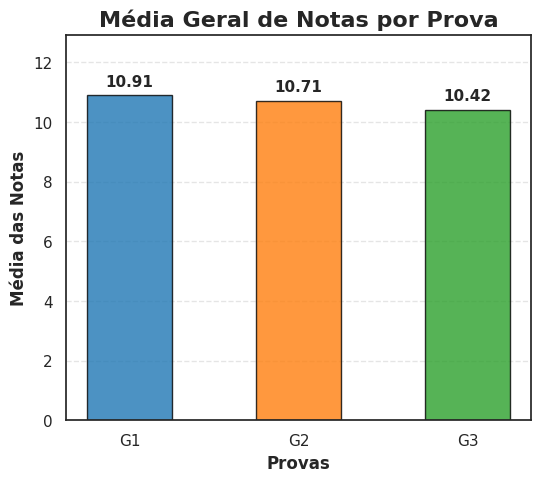

In [96]:
# Importar Biblioteca de Python
import matplotlib.pyplot as plt

# Calcular as Médias das Notas de Cada Prova
medias = df_encoded[['G1', 'G2', 'G3']].mean()
cores = ['#1f77b4', '#ff7f0e', '#2ca02c']

# Exibir Gráfico de Barras
plt.figure(figsize=(6, 5))
plt.bar(medias.index, medias.values, color=cores, width=0.5, edgecolor='black', alpha=0.8)

plt.title('Média Geral de Notas por Prova', fontsize=16, fontweight='bold')
plt.xlabel('Provas', fontsize=12, fontweight='bold')
plt.ylabel('Média das Notas', fontsize=12, fontweight='bold')

for i, valor in enumerate(medias.values):
  plt.text(i, valor + 0.2, f'{valor:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Dar um pequeno espaço no topo do gráfico para o texto não cortar
plt.ylim(0, medias.max() + 2)

# Adicionar linhas de grade apenas no eixo Y
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Exibir o resultado
plt.show()


--- EXIBIÇÃO DO GRÁFICO DE FREQUÊNCIA DE NOTAS ---


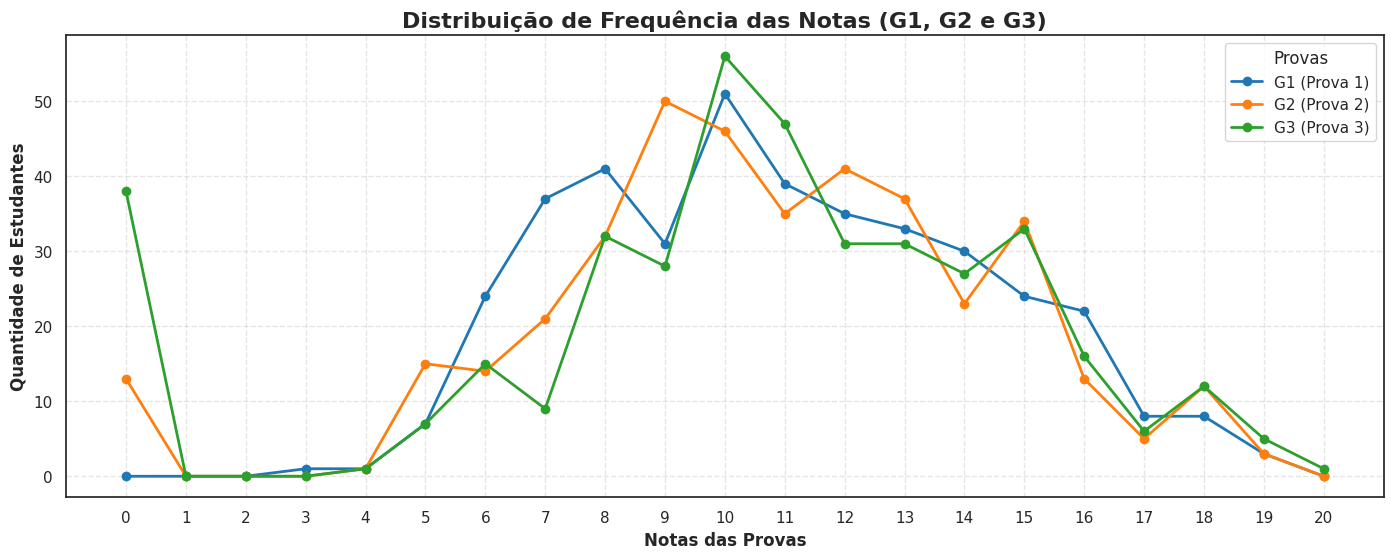

In [97]:
# Definir o Intervalo de Notas Possíveis
nota_minima = 0
nota_maxima = int(df_encoded[['G1', 'G2', 'G3']].max().max())
range_notas = np.arange(nota_minima, nota_maxima + 1)

# Contar a Quantidade de Notas para Cada Prova
frequencia_g1 = df_encoded['G1'].value_counts().reindex(range_notas, fill_value=0)
frequencia_g2 = df_encoded['G2'].value_counts().reindex(range_notas, fill_value=0)
frequencia_g3 = df_encoded['G3'].value_counts().reindex(range_notas, fill_value=0)

# Exibir Gráfico de Frequência
print('\n--- EXIBIÇÃO DO GRÁFICO DE FREQUÊNCIA DE NOTAS ---')
plt.figure(figsize=(17, 6))
plt.plot(range_notas, frequencia_g1, marker='o', label='G1 (Prova 1)', color='#1f77b4', linewidth=2)
plt.plot(range_notas, frequencia_g2, marker='o', label='G2 (Prova 2)', color='#ff7f0e', linewidth=2)
plt.plot(range_notas, frequencia_g3, marker='o', label='G3 (Prova 3)', color='#2ca02c', linewidth=2)

plt.title('Distribuição de Frequência das Notas (G1, G2 e G3)', fontsize=16, fontweight='bold')
plt.xlabel('Notas das Provas', fontsize=12, fontweight='bold')
plt.ylabel('Quantidade de Estudantes', fontsize=12, fontweight='bold')
plt.xticks(range_notas)

plt.legend(fontsize=11, title="Provas")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

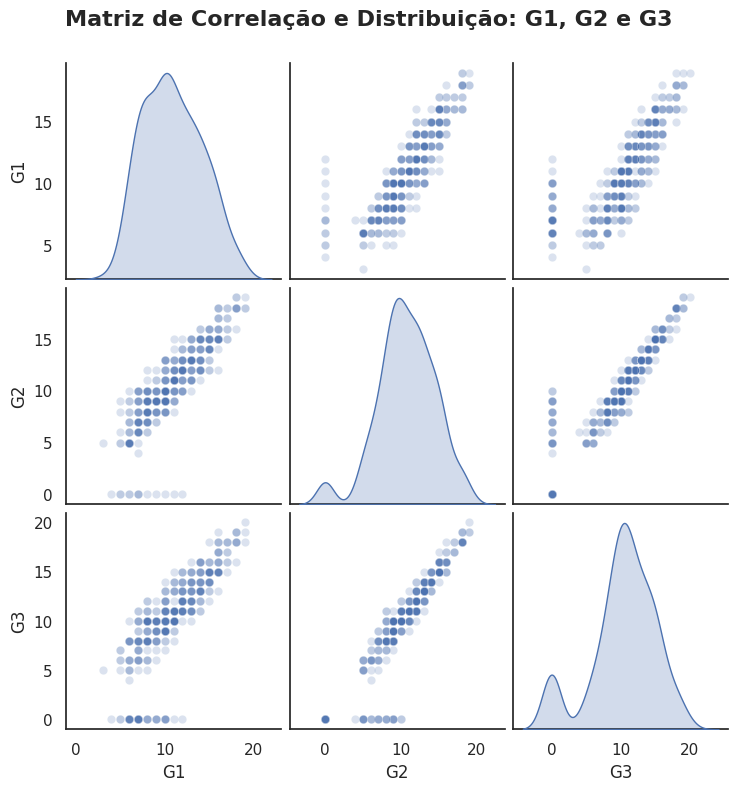

In [98]:
# Importar Biblioteca do Python
import seaborn as sns

# Exibir Matriz de PairPlot
pp = sns.pairplot(df_encoded, vars=['G1', 'G2', 'G3'], diag_kind='kde', plot_kws={'alpha': 0.2})
pp.fig.suptitle('Matriz de Correlação e Distribuição: G1, G2 e G3', y=1.05, fontsize=16, fontweight='bold')
plt.show()

In [143]:
# Importar Bibliotecas do Python
import plotly.graph_objects as go

# Função para Calcular as Frequências das Notas de Cada Prova
def calcular_frequencias(dataframe_filtrado):
  g1_freq = dataframe_filtrado['G1'].value_counts().reindex(range_notas, fill_value=0).values
  g2_freq = dataframe_filtrado['G2'].value_counts().reindex(range_notas, fill_value=0).values
  g3_freq = dataframe_filtrado['G3'].value_counts().reindex(range_notas, fill_value=0).values
  return g1_freq, g2_freq, g3_freq

# Colocar as Informações Iniciais do Gráfico
fig = go.Figure()
f_g1, f_g2, f_g3 = calcular_frequencias(df_encoded)
fig.add_trace(go.Scatter(x=range_notas, y=f_g1, mode='lines+markers', name='G1', line=dict(color='#1f77b4', width=3)))
fig.add_trace(go.Scatter(x=range_notas, y=f_g2, mode='lines+markers', name='G2', line=dict(color='#ff7f0e', width=3)))
fig.add_trace(go.Scatter(x=range_notas, y=f_g3, mode='lines+markers', name='G3', line=dict(color='#2ca02c', width=3)))

# Criar os Eventos do Slider Interativo
steps = []
for nota_limite in range_notas:
  # Filtrar o Dataframe e Recalcular a Frequência de Notas
  df_filtrado = df_encoded[df_encoded['G1'] <= nota_limite]
  freq_g1, freq_g2, freq_g3 = calcular_frequencias(df_filtrado)

  # Atualizar as Informações do Gráfico
  step = dict(
    method='update',
    label=str(nota_limite),
    args=[{'y': [freq_g1, freq_g2, freq_g3]},
      {'title': f'<b>Distribuição de Frequência de Notas para Alunos com Nota G1 <= {nota_limite} ({len(df_filtrado)} alunos) </b>'}],
  )
  steps.append(step)

# Exibir o Gráfico Interativo
sliders = [dict(
    active=len(range_notas) - 1,
    currentvalue={'prefix': 'Filtrar alunos com nota em G1 menor ou igual a: ', 'font': {'size': 14, 'color': 'black'}},
    pad={'t': 60},
    steps=steps
)]

fig.update_layout(
  sliders=sliders,
  title=dict(
    text=f'<b>Distribuição de Frequência de Notas para Alunos com Nota G1 <= {nota_limite} ({len(df_filtrado)} alunos) </b>',
    font=dict(
        family='Arial, sans-serif',
        size=18,
        color='black'
    ),
    x=0.5,
    y=0.95
  ),
  xaxis=dict(
    title=dict(
      text='<b>Notas das Provas</b>',
      font=dict(
        family='Arial, sans-serif',
        size=16,
        color='black'
      ),
    ),
    tickmode='linear',
    tick0=0,
    dtick=1
  ),
  yaxis=dict(
    title=dict(
      text='<b>Quantidade de Estudantes</b>',
      font=dict(
        family='Arial, sans-serif',
        size=16,
        color='black'
      ),
    ),
    hoverformat='d'
  ),
  hovermode='x unified',
  legend_title='Provas'
)

fig.show()

In [142]:
# Colocar as Informações Iniciais do Gráfico
fig = go.Figure()
f_g1, f_g2, f_g3 = calcular_frequencias(df_encoded[df_encoded['G1'] == nota_maxima])
fig.add_trace(go.Scatter(x=range_notas, y=f_g1, mode='lines+markers', name='G1', line=dict(color='#1f77b4', width=3)))
fig.add_trace(go.Scatter(x=range_notas, y=f_g2, mode='lines+markers', name='G2', line=dict(color='#ff7f0e', width=3)))
fig.add_trace(go.Scatter(x=range_notas, y=f_g3, mode='lines+markers', name='G3', line=dict(color='#2ca02c', width=3)))

# Criar os Eventos do Slider Interativo
steps = []
for nota_limite in range_notas:
  # Filtrar o Dataframe e Recalcular a Frequência de Notas
  df_filtrado = df_encoded[df_encoded['G1'] == nota_limite]
  freq_g1, freq_g2, freq_g3 = calcular_frequencias(df_filtrado)

  # Atualizar as Informações do Gráfico
  step = dict(
    method='update',
    label=str(nota_limite),
    args=[{'y': [freq_g1, freq_g2, freq_g3]},
      {'title': f'<b>Distribuição de Frequência de Notas para Alunos com Nota G1 = {nota_limite} ({len(df_filtrado)} alunos) </b>'}],
  )
  steps.append(step)

# Exibir o Gráfico Interativo
sliders = [dict(
    active=len(range_notas) - 1,
    currentvalue={'prefix': 'Filtrar alunos com nota em G1 igual a: ', 'font': {'size': 14, 'color': 'black'}},
    pad={'t': 60},
    steps=steps
)]

fig.update_layout(
  sliders=sliders,
  title=dict(
    text=f'<b>Distribuição de Frequência de Notas para Alunos com Nota G1 <= {nota_limite} ({len(df_filtrado)} alunos) </b>',
    font=dict(
        family='Arial, sans-serif',
        size=18,
        color='black'
    ),
    x=0.5,
    y=0.95
  ),
  xaxis=dict(
    title=dict(
      text='<b>Notas das Provas</b>',
      font=dict(
        family='Arial, sans-serif',
        size=16,
        color='black'
      ),
    ),
    tickmode='linear',
    tick0=0,
    dtick=1
  ),
  yaxis=dict(
    title=dict(
      text='<b>Quantidade de Estudantes</b>',
      font=dict(
        family='Arial, sans-serif',
        size=16,
        color='black'
      ),
    ),
    hoverformat='d'
  ),
  hovermode='x unified',
  legend_title='Provas'
)

fig.show()

## **Etapa 3 - Machine Learning**



### **Etapa 3.1 - Escalonamento/ Normalização**
O dataset tem variáveis numéricas com amplitudes muito diferentes. A coluna age, por exemplo, varia de 15 a 22, enquanto a coluna absences vai de 0 a 75. Quando você alimenta essas variáveis diretamente em um modelo, aquelas com valores maiores acabam tendo mais peso no cálculo simplesmente pelo tamanho dos números, não pela importância real. O escalonamento corrige isso.

A técnica escolhida foi o StandardScaler, que transforma cada valor usando a fórmula do z-score.

In [ ]:
from sklearn.preprocessing import StandardScaler

escalas_colunas = ['age', 'absences', 'G1', 'G2', 'G3']

# Inicializar df_scaled como uma cópia de df_encoded
df_scaled = df_encoded.copy()

# Calcular a média e o desvio padrão de cada coluna a partir dos dados
scaler = StandardScaler()
valores_escalados = scaler.fit_transform(df_scaled[escalas_colunas])

for i, col in enumerate(escalas_colunas):
    df_scaled[f'{col}_scaled'] = valores_escalados[:, i]

print(df_scaled[['age', 'age_scaled', 'absences', 'absences_scaled']].head())

   age  age_scaled  absences  absences_scaled
0   18    1.023046         6         0.036424
1   17    0.238380         4        -0.213796
2   15   -1.330954        10         0.536865
3   15   -1.330954         2        -0.464016
4   16   -0.546287         4        -0.213796
